In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import arrow
from pathlib import Path
import netCDF4 as nc
import pandas as pd
import numpy as np
from cmocean import cm
from salishsea_tools import viz_tools
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)
meshmask0 = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc')
meshmask = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask202605.nc')
tmask0 = meshmask0.tmask
mbathy0 = meshmask0.mbathy
tmask1 = meshmask.tmask
mbathy1 = meshmask.mbathy

mesh = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask202605.nc')
bathy = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202605.nc')
depth = mesh.variables['gdept_1d'][:]


### HOOD CANAL - Ecology data

In [3]:
stations = {
#    'HCB003': (-123.00830, 47.53833),
    'HCB004': (-123.02330, 47.35667),
    'HCB007': (-122.928299, 47.398331),
}
stations_Sources = {
    'HCB003': (-123.00830, 47.53833),
    'ADM003': (-122.48180, 47.87917),
#    'SAR003': (-122.49000, 48.10833),
#    'SKG003': (-122.48830, 48.29667),
}
stationsPC = {                         # Penn Cove stations: to be used for the map and for the evaluation of the model at the station locations
    'PENNCOVEENT': (-122.655, 48.2370),
    'PENNCOVEPNN001': (-122.670, 48.2300),
    'PENNCOVECW': (-122.688, 48.2230),
    'PENNCOVEWEST': (-122.720, 48.2249),
}
station_indices, station_indices_Sources, station_indicesPC = {}, {}, {}

for name, (lon_sta, lat_sta) in stations.items():

    jj = grid_lons_lats.jj.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    ii = grid_lons_lats.ii.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    station_indices[name] = (jj, ii)

    print(name, bathy['Bathymetry'][jj, ii])

for name, (lon_sta, lat_sta) in stations_Sources.items():

    jj = grid_lons_lats.jj.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    ii = grid_lons_lats.ii.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    station_indices_Sources[name] = (jj, ii)

    print(name, bathy['Bathymetry'][jj, ii])

for name, (lon_sta, lat_sta) in stationsPC.items():

    jj = grid_lons_lats.jj.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    ii = grid_lons_lats.ii.sel(lats=lat_sta, lons=lon_sta, method='nearest').item()

    station_indicesPC[name] = (jj, ii)

    print(name, bathy['Bathymetry'][jj, ii])

HCB004 50.0625
HCB007 22.625
HCB003 122.0
ADM003 201.3125
PENNCOVEENT 23.625
PENNCOVEPNN001 26.25
PENNCOVECW 13.125
PENNCOVEWEST 12.25


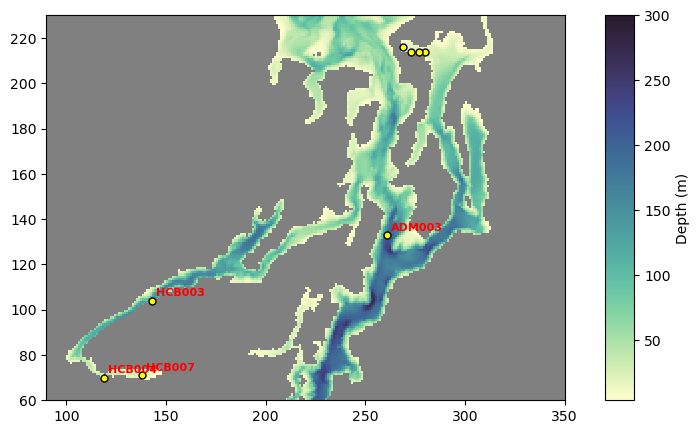

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

mycmap = cm.deep
mycmap.set_bad('grey')

ax.set_xlim([90, 350])
ax.set_ylim([60, 230])

vmin, vmax = (4, 300)

im = ax.pcolormesh(bathy.variables['Bathymetry'][:], cmap=mycmap, vmin=vmin, vmax=vmax)

for name, (jj, ii) in station_indices.items():

    ax.plot(ii, jj, marker='o', color='yellow', markersize=5, markeredgecolor='black')

    ax.text(ii + 2, jj + 2, name, fontsize=8, color='red', weight='bold')

    viz_tools.set_aspect(ax)
for name, (jj, ii) in station_indices_Sources.items():

    ax.plot(ii, jj, marker='o', color='yellow', markersize=5, markeredgecolor='black')

    ax.text(ii + 2, jj + 2, name, fontsize=8, color='red', weight='bold')

    viz_tools.set_aspect(ax)
for name, (jj, ii) in station_indicesPC.items():

    ax.plot(ii, jj, marker='o', color='yellow', markersize=5, markeredgecolor='black')

    #ax.text(ii + 2, jj + 2, name, fontsize=8, color='red', weight='bold')

    viz_tools.set_aspect(ax)

divider = make_axes_locatable(ax)

cax = divider.append_axes('right', size='5%', pad=0.05)

fig.colorbar(im, cax=cax, orientation='vertical', label='Depth (m)')

In [5]:

obs_2012 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20120101_20121231.csv'
)
obs_2013 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20130101_20131231.csv'
)
obs_2014 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20140101_20141231.csv'
)
obs_2015 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20150101_20151231.csv'
)
obs_2016 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20160101_20161231.csv'
)
obs_2017 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20170101_20171231.csv'
)
obs_2018 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20180101_20181231.csv'
)
obs_2019 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20190101_20191231.csv'
)
obs_2020 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20200101_20201231.csv'
)
obs_2021 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20210101_20211231.csv'
)
obs_2022 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20220101_20221231.csv'
)
obs_2023 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20230101_20231231.csv'
)
obs_2024 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/'
    'ObsModel_202410b_eco_from_parker_20240101_20241231.csv'
)
obs = pd.concat([#obs_2012, obs_2013, obs_2014, obs_2015, obs_2016, 
                 obs_2017, obs_2018, obs_2019, 
                 #obs_2020, obs_2021, obs_2022, obs_2023, obs_2024
                 ], ignore_index=True)
obs['dtUTC'] = pd.to_datetime(obs['dtUTC'])

obs.head()

,cid,cruise,dtUTC,Lat,Lon,name,Z,Temperature,Salinity,Oxygen_Dissolved,...,mod_silicon,mod_ammonium,mod_diatoms,mod_flagellates,mod_vosaline,mod_votemper,mod_total_alkalinity,mod_dissolved_inorganic_carbon,mod_dissolved_oxygen,k
0,0.0,NaN,2017-01-11 17:40:16,47.091671,-122.916702,BUD005,7.5,7.272952,28.153545,281.00310,...,43.538502,5.780864,0.332240,0.159439,26.497255,5.218573,1932.416138,1844.208862,280.054169,7
1,0.0,NaN,2017-01-11 17:40:16,47.091671,-122.916702,BUD005,12.0,7.476994,28.254512,269.15936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2,3.0,NaN,2017-01-11 19:33:20,47.161671,-122.870003,DNA001,10.5,7.796616,28.479652,272.33438,...,42.450230,4.614275,0.243505,0.150305,28.210382,7.875945,2018.923950,1936.225098,234.631409,10
3,3.0,NaN,2017-01-11 19:33:20,47.161671,-122.870003,DNA001,30.5,7.843337,28.514379,271.45312,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
4,2.0,NaN,2017-01-11 20:16:00,47.264999,-122.843300,CSE001,1.0,8.170211,28.786239,268.26562,...,41.658417,4.522013,0.229886,0.147549,28.627567,8.380248,2039.651245,1955.178589,224.486801,0


HCB004 50.0625
HCB007 22.625


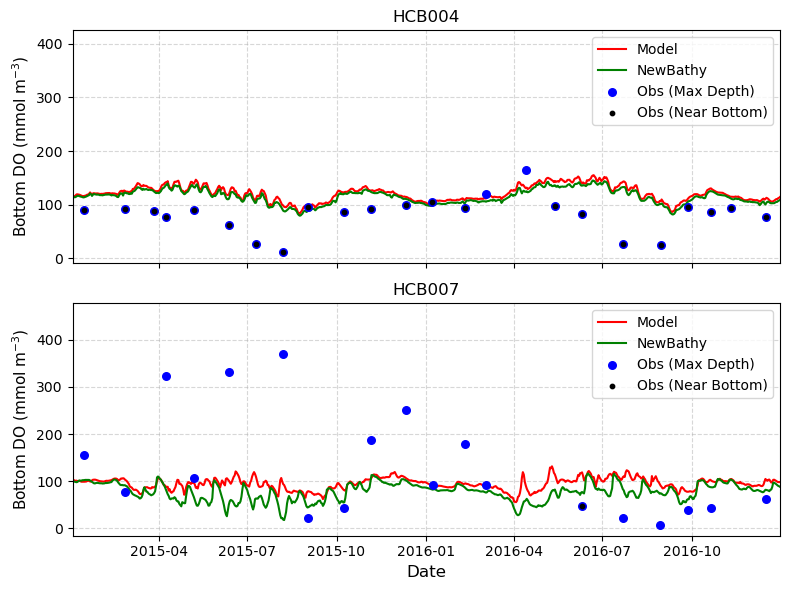

In [ ]:
place = list(stations.keys())
fig, ax = plt.subplots(
    len(place),
    1,
    figsize=(8, 6),
    sharex=True
)
syear, smonth, sday = (2015, 1, 2)
eyear, emonth, eday = (2016, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate   = arrow.get(eyear, emonth, eday)
ylabel = 'Bottom DO (mmol m$^{-3}$)'

simulations = [
    {
        'dir': '/ocean/atall/MOAD/Model/202410b_updated/',
        'color': 'red',
        'label': 'Model',
        'mbathy': mbathy0,
        'tmask': tmask0,
    },
    {
        'dir': '/ocean/atall/MOAD/Model/202410b_NewBathyHC/notNOAA/',
        'color': 'green',
        'label': 'NewBathy',
        'mbathy': mbathy1,
        'tmask': tmask1,
    },
    
]
for sim in simulations:

    sim_dir = sim['dir']
    color   = sim['color']
    label   = sim['label']
    mbathy  = sim['mbathy']
    tmask   = sim['tmask']

    for j, station_name in enumerate(place):

        jj, ii = station_indices[station_name]

        oxy_list = []
        time_list = []

        for day_arrow in arrow.Arrow.range('day', startdate, enddate):
            year  = day_arrow.year
            yr2   = day_arrow.strftime("%y")
            month = day_arrow.month
            Month = day_arrow.strftime("%b").lower()
            day   = day_arrow.day

            fchem = (
                f'{sim_dir}{day:02}{Month}{yr2}/'
                f'SalishSea_1d_'
                f'{year}{month:02}{day:02}_'
                f'{year}{month:02}{day:02}_chem_T.nc'
            )
            with xr.open_dataset(fchem) as ds_chem:
                k = int(mbathy[0, jj, ii] - 1)
                oxy_val = ds_chem['dissolved_oxygen'][0, k, jj, ii].values
                oxy_list.append(float(oxy_val))
                time_list.append(day_arrow.datetime)

        ax[j].plot(time_list, oxy_list, color=color, label=label, linewidth=1.5)
for j, station_name in enumerate(place):
    obs_station = obs[obs['name'] == station_name].copy()
    
    # Sécuriser le format de date
    obs_station['dtUTC'] = pd.to_datetime(obs_station['dtUTC'])
    obs_station['date_only'] = obs_station['dtUTC'].dt.date

    idx_bottom_fromZ = (obs_station.groupby('date_only')['Z'].idxmax())
    obs_bottom_fromZ = obs_station.loc[idx_bottom_fromZ]

    ax[j].scatter(obs_bottom_fromZ['dtUTC'], obs_bottom_fromZ['Oxygen_Dissolved'], color='b', s=30, label='Obs (Max Depth)', zorder=10)

    jj, ii = station_indices[station_name]
    k_bottom = int(mbathy0[0, jj, ii] - 1)
    print(station_name, bathy['Bathymetry'][jj, ii])
    obs_station['k_model'] = obs_station['k'].apply(
            lambda z: np.abs(depth - z).argmin()
    )
    obs_bottom = obs_station[obs_station['k'] >= (k_bottom - 1)].copy()
        
    ax[j].scatter(obs_bottom['dtUTC'], obs_bottom['Oxygen_Dissolved'], color='k', s=10, label='Obs (Near Bottom)', zorder=10)

    ax[j].set_ylabel(ylabel, fontsize=11)
    ax[j].set_title(station_name, fontsize=12)
    ax[j].grid(True, linestyle='--', alpha=0.5)
    ax[j].legend(loc='upper right')
    ax[j].set_xlim(startdate.datetime, enddate.datetime)

ax[-1].set_xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show() 


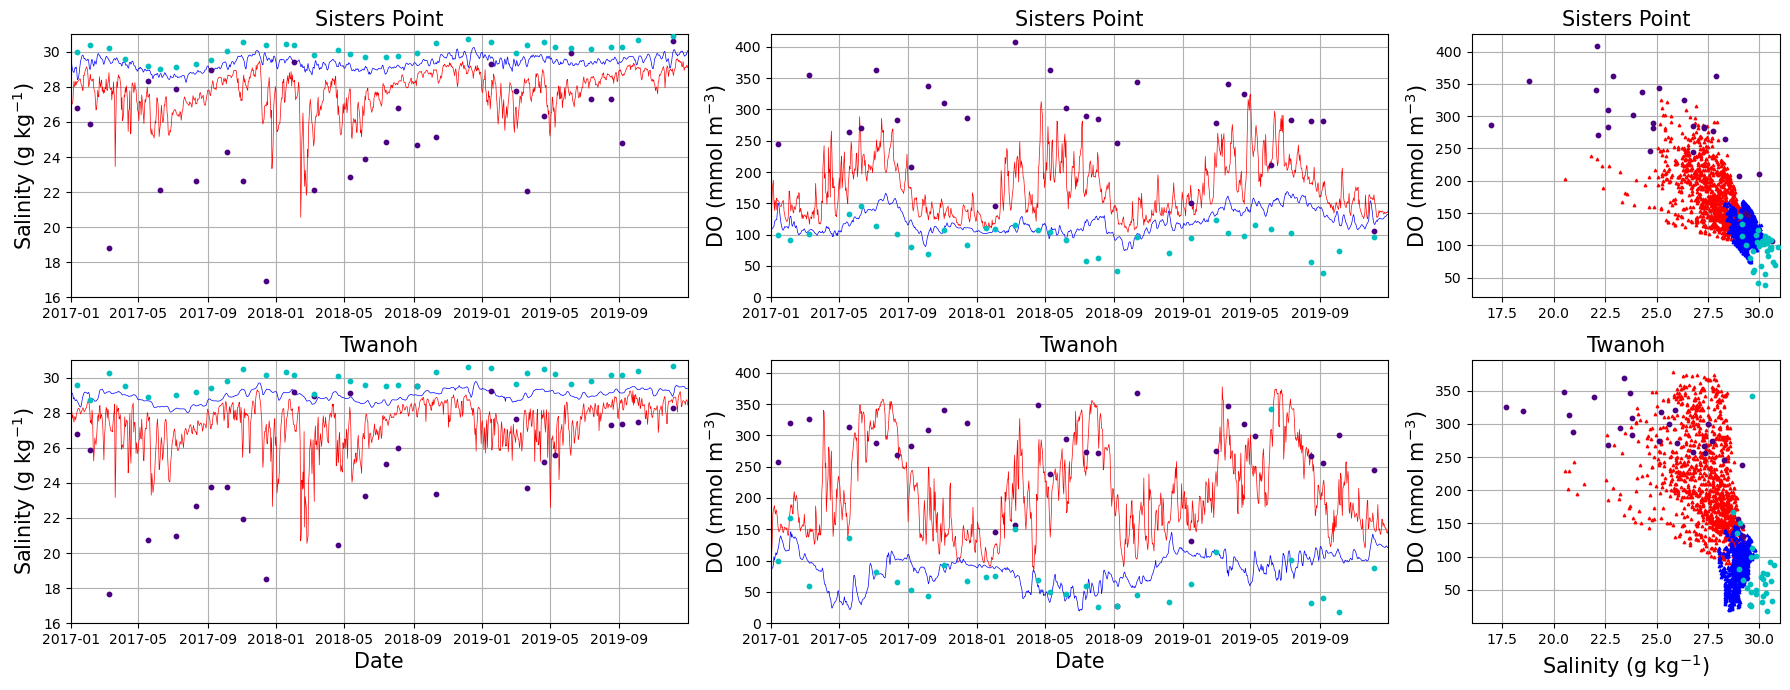

In [75]:
place = list(stations.keys())

fig, ax = plt.subplots(
    len(place),
    3,
    figsize=(18, 7),
    #sharex=True,
    gridspec_kw={'width_ratios': [2, 2, 1]}
)

#sim_dir = '/ocean/atall/MOAD/Model/202410b_updated/'
sim_dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
mbathy = mbathy0 # To be updated to mbathy1 once it's ready

syear, smonth, sday = (2017, 1, 1)
eyear, emonth, eday = (2019, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate   = arrow.get(eyear, emonth, eday)
ylabel = 'Bottom DO (mmol m$^{-3}$)'

for j, station_name in enumerate(place):

    jj, ii = station_indices[station_name]

    oxyS_list, oxyB_list = [], []
    SalS_list, SalB_list = [], []
    time_list = []

    for day_arrow in arrow.Arrow.range('day', startdate, enddate):
        year  = day_arrow.year
        yr2   = day_arrow.strftime("%y")
        month = day_arrow.month
        Month = day_arrow.strftime("%b").lower()
        day   = day_arrow.day

        fgrid = (
            f'{sim_dir}{day:02}{Month}{yr2}/'
            f'SalishSea_1d_'
            f'{year}{month:02}{day:02}_'
            f'{year}{month:02}{day:02}_grid_T.nc'
        )
        with xr.open_dataset(fgrid) as ds_grid:
            k = int(mbathy[0, jj, ii] - 1)
            SalS_val = ds_grid['vosaline'][0, 4, jj, ii].values
            SalB_val = ds_grid['vosaline'][0, k, jj, ii].values
            SalS_list.append(float(SalS_val))
            SalB_list.append(float(SalB_val))
            time_list.append(day_arrow.datetime)
        fchem = (
            f'{sim_dir}{day:02}{Month}{yr2}/'
            f'SalishSea_1d_'
            f'{year}{month:02}{day:02}_'
            f'{year}{month:02}{day:02}_chem_T.nc'
        )
        with xr.open_dataset(fchem) as ds_chem:
            k = int(mbathy[0, jj, ii] - 1)
            oxyS_val = ds_chem['dissolved_oxygen'][0, 4, jj, ii].values
            oxyB_val = ds_chem['dissolved_oxygen'][0, k, jj, ii].values
            oxyS_list.append(float(oxyS_val))
            oxyB_list.append(float(oxyB_val))

    ax[j,0].plot(time_list, SalS_list, color='r', linewidth=0.5)
    ax[j,0].plot(time_list, SalB_list, color='b', linewidth=0.5)
    ax[j,1].plot(time_list, oxyS_list, color='r', linewidth=0.5)
    ax[j,1].plot(time_list, oxyB_list, color='b', linewidth=0.5)
    ax[j,2].scatter(SalS_list, oxyS_list, marker='^', color='r', s=3, label='Surface', zorder=10)
    ax[j,2].scatter(SalB_list, oxyB_list, marker='^', color='b', s=3, label='Bottom', zorder=10)
for j, station_name in enumerate(place):
    obs_station = obs[obs['name'] == station_name].copy()
    obs_station['date_only'] = obs_station['dtUTC'].dt.date

    idx_surface = (obs_station.groupby('date_only')['Z'].idxmin())
    obs_surface = obs_station.loc[idx_surface]
    idx_bottom = (obs_station.groupby('date_only')['Z'].idxmax())
    obs_bottom = obs_station.loc[idx_bottom]

    ax[j,0].scatter(obs_surface['dtUTC'], obs_surface['Salinity'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,0].scatter(obs_bottom['dtUTC'], obs_bottom['Salinity'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,1].scatter(obs_surface['dtUTC'], obs_surface['Oxygen_Dissolved'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,1].scatter(obs_bottom['dtUTC'], obs_bottom['Oxygen_Dissolved'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,2].scatter(obs_surface['Salinity'], obs_surface['Oxygen_Dissolved'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,2].scatter( obs_bottom['Salinity'], obs_bottom['Oxygen_Dissolved'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,0].set_ylabel('Salinity (g kg$^{-1}$)', fontsize=15)
    ax[j,1].set_ylabel('DO (mmol m$^{-3}$)', fontsize=15)
    ax[j,2].set_ylabel('DO (mmol m$^{-3}$)', fontsize=15)
    ax[j,0].set_ylim(16, 31)
    ax[j,1].set_ylim(0, 420)
    ax[j,0].grid(True)
    ax[j,1].grid(True)
    ax[j,2].grid(True)
    #ax[j,0].legend()
    ax[j,0].set_xlim(startdate.datetime, enddate.datetime)
    ax[j,1].set_xlim(startdate.datetime, enddate.datetime)
    ax[j,2].set_xlim(16, 31)

ax[0,0].set_title('Sisters Point', fontsize=15)
ax[0,1].set_title('Sisters Point', fontsize=15)
ax[0,2].set_title('Sisters Point', fontsize=15)
ax[1,0].set_title('Twanoh', fontsize=15)
ax[1,1].set_title('Twanoh', fontsize=15)
ax[1,2].set_title('Twanoh', fontsize=15)
ax[-1,0].set_xlabel('Date', fontsize=15)
ax[-1,1].set_xlabel('Date', fontsize=15)
ax[-1, 2].set_xlabel('Salinity (g kg$^{-1}$)', fontsize=15)

plt.tight_layout()

plt.show()

#### Sources stations: surface & bottom timeseries

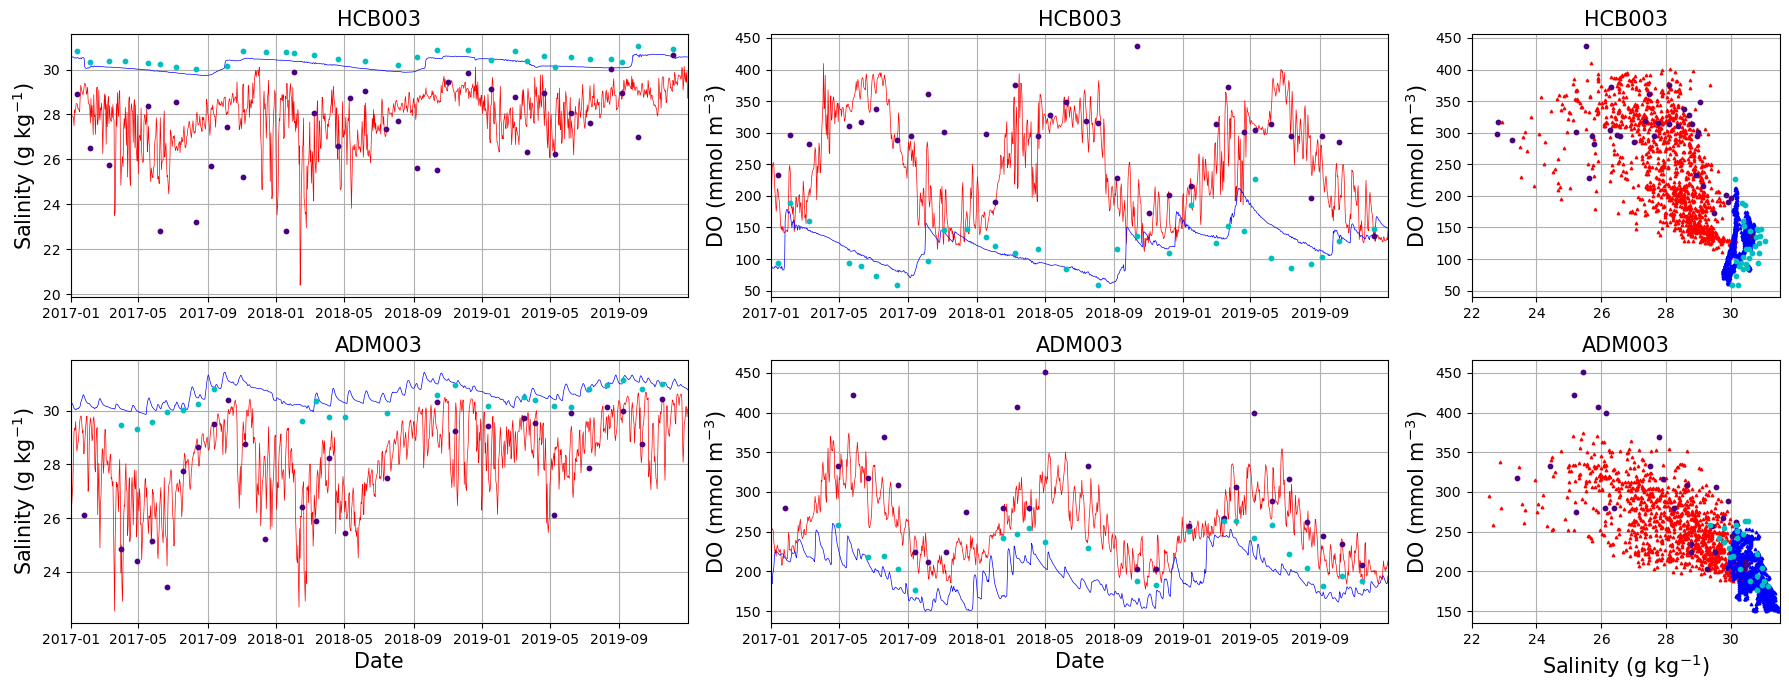

In [76]:
place_Sources = list(stations_Sources.keys())

fig, ax = plt.subplots(
    len(place_Sources),
    3,
    figsize=(18, 7),
    #sharex=True,
    gridspec_kw={'width_ratios': [2, 2, 1]}
)

sim_dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
mbathy = mbathy0 # To be updated to mbathy1 once it's ready

syear, smonth, sday = (2017, 1, 1)
eyear, emonth, eday = (2019, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate   = arrow.get(eyear, emonth, eday)

for j, station_nameSources in enumerate(place_Sources):

    jj, ii = station_indices_Sources[station_nameSources]

    oxyS_list, oxyB_list = [], []
    SalS_list, SalB_list = [], []
    time_list = []

    for day_arrow in arrow.Arrow.range('day', startdate, enddate):
        year  = day_arrow.year
        yr2   = day_arrow.strftime("%y")
        month = day_arrow.month
        Month = day_arrow.strftime("%b").lower()
        day   = day_arrow.day

        fgrid = (
            f'{sim_dir}{day:02}{Month}{yr2}/'
            f'SalishSea_1d_'
            f'{year}{month:02}{day:02}_'
            f'{year}{month:02}{day:02}_grid_T.nc'
        )
        with xr.open_dataset(fgrid) as ds_grid:
            k = int(mbathy[0, jj, ii] - 1)
            SalS_val = ds_grid['vosaline'][0, 4, jj, ii].values
            SalB_val = ds_grid['vosaline'][0, k, jj, ii].values
            SalS_list.append(float(SalS_val))
            SalB_list.append(float(SalB_val))
            time_list.append(day_arrow.datetime)
        fchem = (
            f'{sim_dir}{day:02}{Month}{yr2}/'
            f'SalishSea_1d_'
            f'{year}{month:02}{day:02}_'
            f'{year}{month:02}{day:02}_chem_T.nc'
        )
        with xr.open_dataset(fchem) as ds_chem:
            k = int(mbathy[0, jj, ii] - 1)
            oxyS_val = ds_chem['dissolved_oxygen'][0, 4, jj, ii].values
            oxyB_val = ds_chem['dissolved_oxygen'][0, k, jj, ii].values
            oxyS_list.append(float(oxyS_val))
            oxyB_list.append(float(oxyB_val))

    ax[j,0].plot(time_list, SalS_list, color='r', linewidth=0.5)
    ax[j,0].plot(time_list, SalB_list, color='b', linewidth=0.5)
    ax[j,1].plot(time_list, oxyS_list, color='r', linewidth=0.5)
    ax[j,1].plot(time_list, oxyB_list, color='b', linewidth=0.5)
    ax[j,2].scatter(SalS_list, oxyS_list, marker='^', color='r', s=3, label='Surface', zorder=10)
    ax[j,2].scatter(SalB_list, oxyB_list, marker='^', color='b', s=3, label='Bottom', zorder=10)
for j, station_nameSources in enumerate(place_Sources):
    obs_station = obs[obs['name'] == station_nameSources].copy()
    obs_station['date_only'] = obs_station['dtUTC'].dt.date

    idx_surface = (obs_station.groupby('date_only')['Z'].idxmin())
    obs_surface = obs_station.loc[idx_surface]
    idx_bottom = (obs_station.groupby('date_only')['Z'].idxmax())
    obs_bottom = obs_station.loc[idx_bottom]

    ax[j,0].scatter(obs_surface['dtUTC'], obs_surface['Salinity'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,0].scatter(obs_bottom['dtUTC'], obs_bottom['Salinity'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,1].scatter(obs_surface['dtUTC'], obs_surface['Oxygen_Dissolved'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,1].scatter(obs_bottom['dtUTC'], obs_bottom['Oxygen_Dissolved'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,2].scatter(obs_surface['Salinity'], obs_surface['Oxygen_Dissolved'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,2].scatter( obs_bottom['Salinity'], obs_bottom['Oxygen_Dissolved'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,0].set_ylabel('Salinity (g kg$^{-1}$)', fontsize=15)
    ax[j,1].set_ylabel('DO (mmol m$^{-3}$)', fontsize=15)
    ax[j,2].set_ylabel('DO (mmol m$^{-3}$)', fontsize=15)
    ax[j,0].set_title(station_nameSources, fontsize=15)
    ax[j,1].set_title(station_nameSources, fontsize=15)
    ax[j,2].set_title(station_nameSources, fontsize=15)
    ax[j,0].grid(True)
    ax[j,1].grid(True)
    ax[j,2].grid(True)
    #ax[j,0].legend()
    ax[j,0].set_xlim(startdate.datetime, enddate.datetime)
    ax[j,1].set_xlim(startdate.datetime, enddate.datetime)
    ax[j,2].set_xlim(22, 31.5)

ax[-1, 0].set_xlabel('Date', fontsize=15)
ax[-1, 1].set_xlabel('Date', fontsize=15)
ax[-1, 2].set_xlabel('Salinity (g kg$^{-1}$)', fontsize=15)

plt.tight_layout()

plt.show()

#### Penn Cove - KC data - 2022 only

In [6]:
obs_2022pc = pd.read_csv("/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_from_KC_20220101_20221231.csv")
obs_2023pc = pd.read_csv("/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_from_KC_20230101_20231231.csv")
obs_2024pc = pd.read_csv("/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_from_KC_20240101_20241231.csv")
obs_pc = pd.concat([obs_2022pc, obs_2023pc, obs_2024pc], ignore_index=True)
obs_pc["dtUTC"] = pd.to_datetime(obs_pc["dtUTC"])
obs_pc.head()

,Unnamed: 0,Z,Locator,CH Qual,DO Qual,NO23 Qual,SA Qual,Sample Date,Summ Row ID,Up Down,...,mod_silicon,mod_ammonium,mod_diatoms,mod_flagellates,mod_vosaline,mod_votemper,mod_total_alkalinity,mod_dissolved_inorganic_carbon,mod_dissolved_oxygen,k
0,496,1.0,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:12:59 PM,NaN,Down,...,74.265152,5.967259,0.428045,0.265784,16.456305,5.420424,1446.524658,1420.170532,325.527740,0
1,497,2.0,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:13:38 PM,NaN,Down,...,74.251862,5.966934,0.429224,0.265821,16.462175,5.419395,1446.832520,1420.453857,325.436890,1
2,498,2.5,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:13:41 PM,NaN,Down,...,73.869270,5.959213,0.438249,0.267005,16.594326,5.448007,1453.395874,1426.378784,325.118011,2
3,499,3.0,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:13:43 PM,NaN,Down,...,73.869270,5.959213,0.438249,0.267005,16.594326,5.448007,1453.395874,1426.378784,325.118011,2
4,500,3.5,PENNCOVEENT,NaN,NaN,NaN,NaN,02/03/2022 12:13:45 PM,NaN,Down,...,72.147324,5.905107,0.456280,0.271853,17.192875,5.538764,1483.211914,1453.277466,325.497833,3


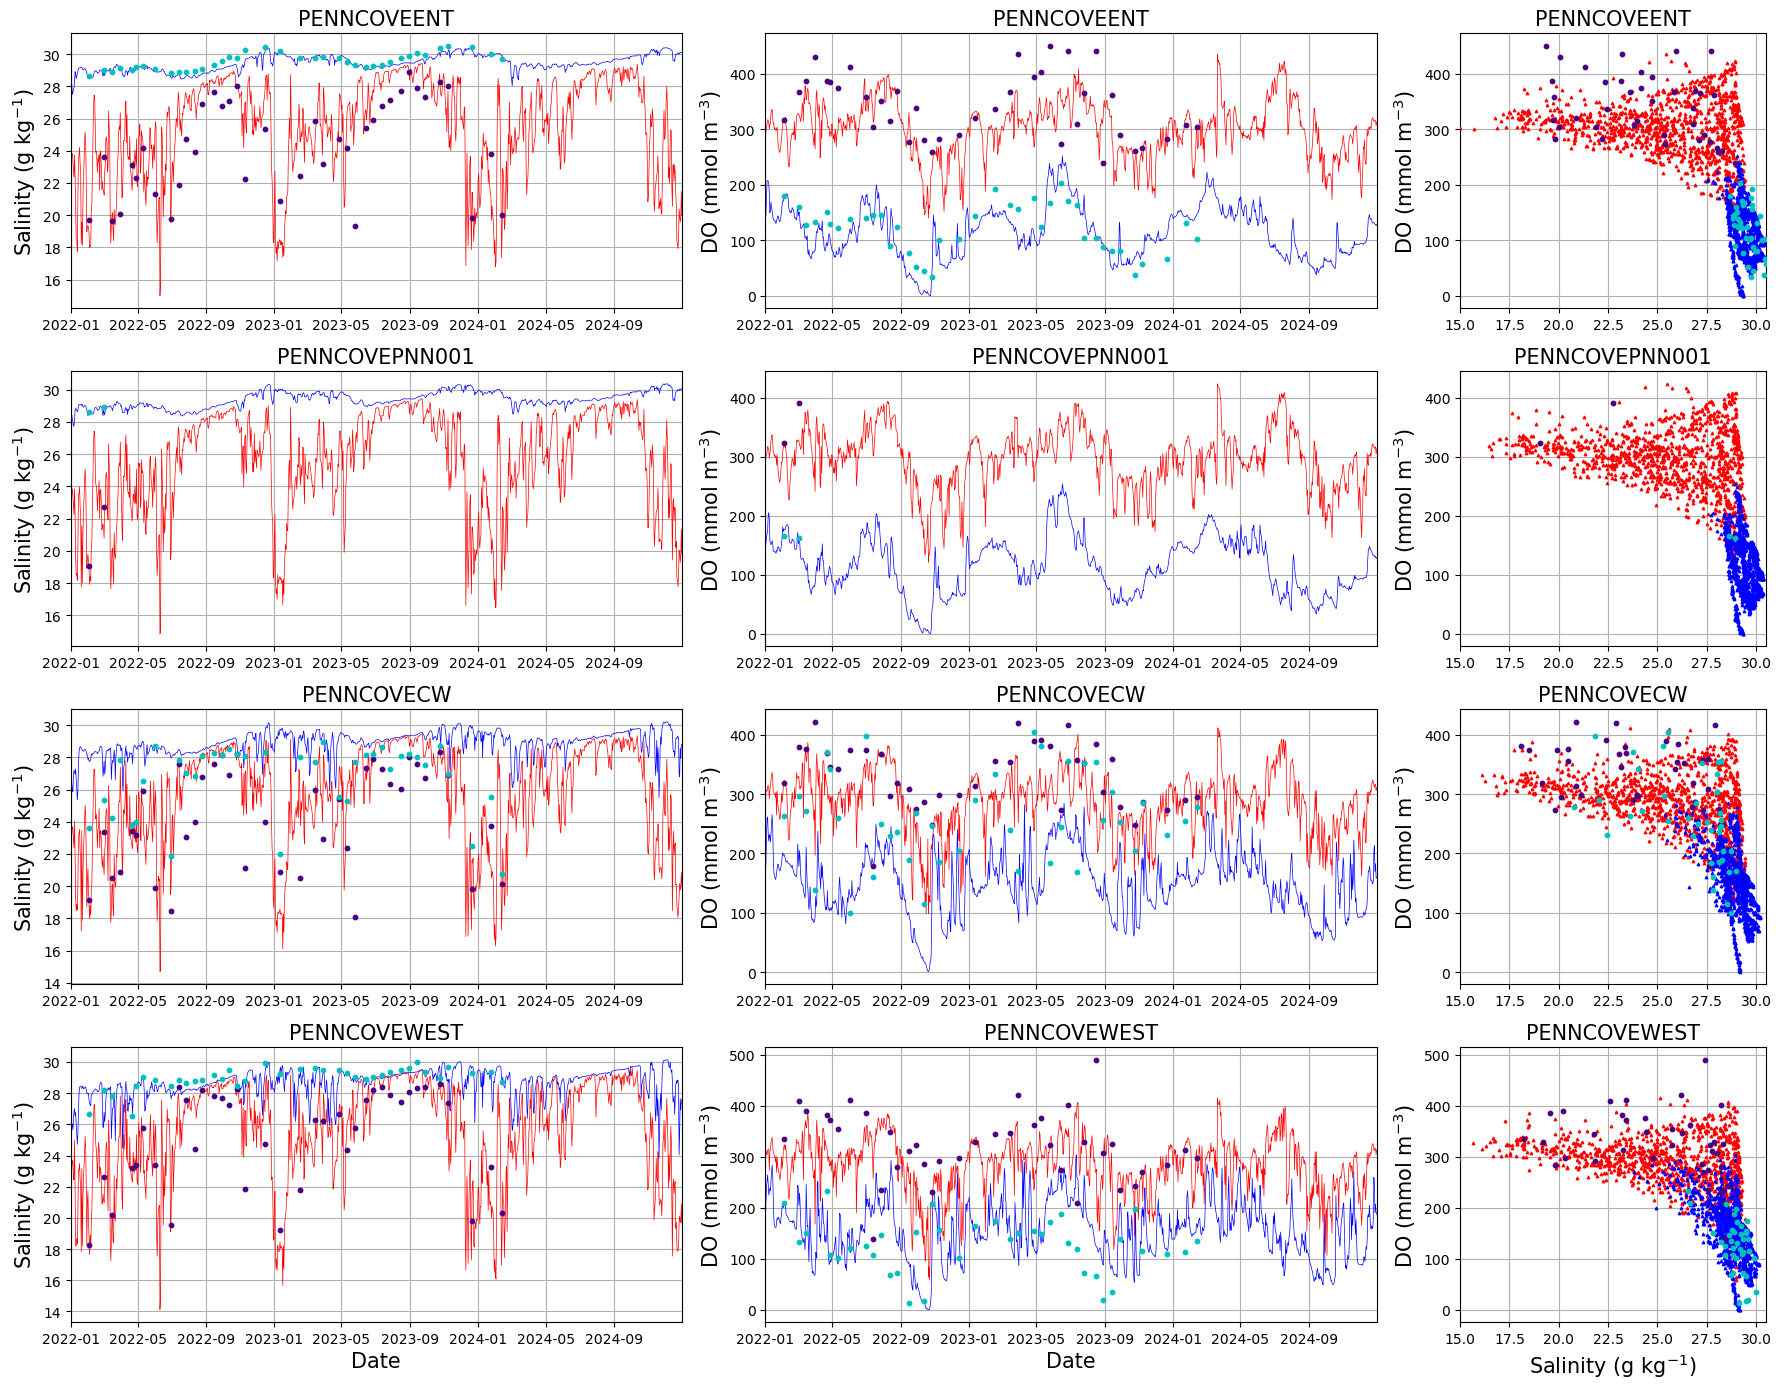

In [7]:
placePC = list(stationsPC.keys())

fig, ax = plt.subplots(
    len(placePC),
    3,
    figsize=(18, 14),
    #sharex=True,
    gridspec_kw={'width_ratios': [2, 2, 1]}
)
syear, smonth, sday = (2022, 1, 1)
eyear, emonth, eday = (2024, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate   = arrow.get(eyear, emonth, eday)

sim_dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
mbathy = mbathy0 # To be updated to mbathy1 once it's ready


for j, station_namePC in enumerate(placePC):

    jj, ii = station_indicesPC[station_namePC]

    oxyS_list, oxyB_list = [], []
    SalS_list, SalB_list = [], []
    time_list = []

    for day_arrow in arrow.Arrow.range('day', startdate, enddate):
        year  = day_arrow.year
        yr2   = day_arrow.strftime("%y")
        month = day_arrow.month
        Month = day_arrow.strftime("%b").lower()
        day   = day_arrow.day

        fgrid = (
            f'{sim_dir}{day:02}{Month}{yr2}/'
            f'SalishSea_1d_'
            f'{year}{month:02}{day:02}_'
            f'{year}{month:02}{day:02}_grid_T.nc'
        )
        with xr.open_dataset(fgrid) as ds_grid:
            k = int(mbathy[0, jj, ii] - 1)
            SalS_val = ds_grid['vosaline'][0, 4, jj, ii].values
            SalB_val = ds_grid['vosaline'][0, k, jj, ii].values
            SalS_list.append(float(SalS_val))
            SalB_list.append(float(SalB_val))
            time_list.append(day_arrow.datetime)
        fchem = (
            f'{sim_dir}{day:02}{Month}{yr2}/'
            f'SalishSea_1d_'
            f'{year}{month:02}{day:02}_'
            f'{year}{month:02}{day:02}_chem_T.nc'
        )
        with xr.open_dataset(fchem) as ds_chem:
            k = int(mbathy[0, jj, ii] - 1)
            oxyS_val = ds_chem['dissolved_oxygen'][0, 4, jj, ii].values
            oxyB_val = ds_chem['dissolved_oxygen'][0, k, jj, ii].values
            oxyS_list.append(float(oxyS_val))
            oxyB_list.append(float(oxyB_val))

    ax[j,0].plot(time_list, SalS_list, color='r', linewidth=0.5)
    ax[j,0].plot(time_list, SalB_list, color='b', linewidth=0.5)
    ax[j,1].plot(time_list, oxyS_list, color='r', linewidth=0.5)
    ax[j,1].plot(time_list, oxyB_list, color='b', linewidth=0.5)
    ax[j,2].scatter(SalS_list, oxyS_list, marker='^', color='r', s=3, label='Surface', zorder=10)
    ax[j,2].scatter(SalB_list, oxyB_list, marker='^', color='b', s=3, label='Bottom', zorder=10)
for j, station_namePC in enumerate(placePC):
    obs_stationPC = obs_pc[obs_pc['Locator'] == station_namePC].copy()
    obs_stationPC['date_only'] = obs_stationPC['dtUTC'].dt.date
    
    idx_surface = (obs_stationPC.groupby('date_only')['Z'].idxmin())
    obs_surface = obs_stationPC.loc[idx_surface]
    idx_bottom = (obs_stationPC.groupby('date_only')['Z'].idxmax())
    obs_bottom = obs_stationPC.loc[idx_bottom]

    ax[j,0].scatter(obs_surface['dtUTC'], obs_surface['Salinity'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,0].scatter(obs_bottom['dtUTC'], obs_bottom['Salinity'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,1].scatter(obs_surface['dtUTC'], obs_surface['Oxygen_Dissolved'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,1].scatter(obs_bottom['dtUTC'], obs_bottom['Oxygen_Dissolved'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,2].scatter(obs_surface['Salinity'], obs_surface['Oxygen_Dissolved'], color='indigo', s=10, label='Surface', zorder=10)
    ax[j,2].scatter( obs_bottom['Salinity'], obs_bottom['Oxygen_Dissolved'], color='c', s=10, label='Bottom', zorder=10)
    ax[j,0].set_ylabel('Salinity (g kg$^{-1}$)', fontsize=15)
    ax[j,1].set_ylabel('DO (mmol m$^{-3}$)', fontsize=15)
    ax[j,2].set_ylabel('DO (mmol m$^{-3}$)', fontsize=15)
    ax[j,0].set_title(station_namePC, fontsize=15)
    ax[j,1].set_title(station_namePC, fontsize=15)
    ax[j,2].set_title(station_namePC, fontsize=15)
    ax[j,0].grid(True)
    ax[j,1].grid(True)
    ax[j,2].grid(True)
    #ax[j,0].legend()
    ax[j,0].set_xlim(startdate.datetime, enddate.datetime)
    ax[j,1].set_xlim(startdate.datetime, enddate.datetime)
    ax[j,2].set_xlim(15, 30.5)

ax[-1,0].set_xlabel('Date', fontsize=15)
ax[-1,1].set_xlabel('Date', fontsize=15)
ax[-1, 2].set_xlabel('Salinity (g kg$^{-1}$)', fontsize=15)

plt.tight_layout()

plt.show()

#### Profiles: Source Water, Lynch Cove, Penn Cove

In [23]:
def get_season(month):
    if month in [12, 1, 2]:   return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                     return 'Fall'

obs['season'] = obs['dtUTC'].dt.month.map(get_season)
obs_pc['season'] = obs_pc['dtUTC'].dt.month.map(get_season)
columns_list = ['Winter', 'Spring', 'Summer', 'Fall']

list_obs = list(stations.keys())      
list_obs_sources = list(stations_Sources.keys())  
list_obs_pc = list(stationsPC.keys())  

sim_dir = '/ocean/atall/MOAD/Model/202410b/oxygen/' # To be changed to the updated version

In [24]:
depth = np.squeeze(depth)

Text(0.5, 0, 'Date')

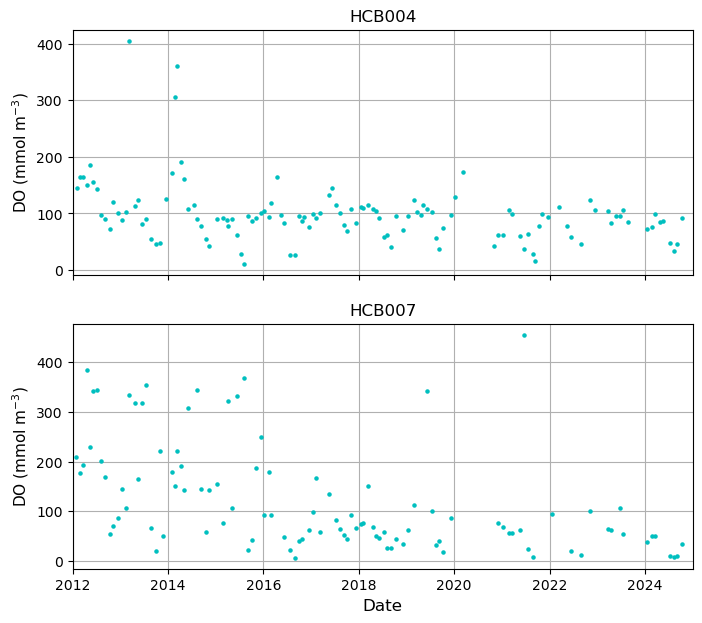

In [19]:
place = list(stations.keys())

fig, ax = plt.subplots(
    len(place),
    1,
    figsize=(8, 7),
    sharex=True
)

syear, smonth, sday = (2012, 1, 1)
eyear, emonth, eday = (2024, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate   = arrow.get(eyear, emonth, eday)
ylabel = 'Bottom DO (mmol m$^{-3}$)'

for j, station_name in enumerate(place):
    obs_station = obs[obs['name'] == station_name].copy()
    obs_station['date_only'] = obs_station['dtUTC'].dt.date

    idx_bottom = (obs_station.groupby('date_only')['Z'].idxmax())
    obs_bottom = obs_station.loc[idx_bottom]

    #ax[j,0].scatter(obs_bottom['dtUTC'], obs_bottom['Salinity'], color='c', s=5, label='Bottom', zorder=10)
    ax[j].scatter(obs_bottom['dtUTC'], obs_bottom['Oxygen_Dissolved'], color='c', s=5, label='Bottom', zorder=10)
    ax[j].set_ylabel('Salinity (g kg$^{-1}$)', fontsize=11)
    ax[j].set_ylabel('DO (mmol m$^{-3}$)', fontsize=11)
    ax[j].set_title(station_name, fontsize=12)
    ax[j].set_title(station_name, fontsize=12)
    ax[j].grid(True)
    ax[j].grid(True)
    #ax[j,0].legend()
    ax[j].set_xlim(startdate.datetime, enddate.datetime)
    ax[j].set_xlim(startdate.datetime, enddate.datetime)

ax[-1].set_xlabel('Date', fontsize=12)
ax[-1].set_xlabel('Date', fontsize=12)
